In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from extractDataSrc.Hapi import get_hapi_data
from extractDataSrc.InSitu import InSitu


In [33]:

start = '1998-05-04 00:00'
end   = '1998-05-04 10:00'
# Constants
server = 'https://cdaweb.gsfc.nasa.gov/hapi'
dataset = 'OMNI2_H0_MRG1HR'

# 1. Download ap index (Hourly/3-hourly) -----------------
print('Downloading ap index (Hourly dataset) -----------------')
parameter_ap = 'AP_INDEX1800'

hapi_ap = get_hapi_data(server, dataset, parameter_ap, start, end)

ap_list = []
for record in hapi_ap:
    row = [record[0], round(record[1], 3)]
    ap_list.append(row)

ap = pd.DataFrame(data=ap_list, columns=["Time", 'ap'])
ap['Time'] = ap['Time'].str.decode('utf-8')
ap.index = pd.to_datetime(ap['Time'], format="%Y-%m-%dT%H:%M:%S.000Z")
ap.drop('Time', axis=1, inplace=True)

print("Done with ap")

# 2. Download PC(N) index (Hourly) -----------------
print('Downloading PC(N) index (Hourly dataset) -----------------')
parameter_pcn = 'PC_N_INDEX1800'

hapi_pcn = get_hapi_data(server, dataset, parameter_pcn, start, end)

pcn_list = []
for record in hapi_pcn:
    row = [record[0], round(record[1], 3)]
    pcn_list.append(row)

PCN = pd.DataFrame(data=pcn_list, columns=["Time", 'PCN'])
PCN['Time'] = PCN['Time'].str.decode('utf-8')
PCN.index = pd.to_datetime(PCN['Time'], format="%Y-%m-%dT%H:%M:%S.000Z")
PCN.drop('Time', axis=1, inplace=True)


print("Done with PCN")

Done with ap
Done with PCN


In [34]:
ap.max(), PCN.max()

(ap    300
 dtype: int32,
 PCN    11.0
 dtype: float64)

In [22]:
from datetime import datetime, timedelta

start = '2000-09-17 21:00:00'
hours_to_add = 10

start_dt = datetime.strptime(start, '%Y-%m-%d %H:%M:%S')
end_dt = start_dt + timedelta(hours=hours_to_add)
end = end_dt.strftime('%Y-%m-%d %H:%M:%S')

print(end)

print('Downloading SOHO CELIAS V_p (30s cadence) -----------------')
insitu = InSitu(start, end)
insitu.extract_data("V_p", verbose=True)

V = pd.read_csv('./data_processed/in_situ/B_data.csv')
V.index = pd.to_datetime(V['Time'])
V.drop('Time', axis=1, inplace=True)

V = V.resample('3min').mean()

print('Downloading SYM_H -----------------')
server = 'https://cdaweb.gsfc.nasa.gov/hapi'
dataset = 'OMNI_HRO_1MIN'
parameter = 'SYM_H'

hapi_data = get_hapi_data(server, dataset, parameter, start, end)

SYM_data = []
for record in hapi_data:
    row = []
    row.append(record[0])
    row.append(round(record[1], 3))
    SYM_data.append(row)

SYM_H = pd.DataFrame(data=SYM_data, columns=["Time", 'SYM_H'])
SYM_H['Time'] = SYM_H['Time'].str.decode('utf-8')
SYM_H.index = pd.to_datetime(SYM_H['Time'], format="%Y-%m-%dT%H:%M:%S.000Z")
SYM_H.drop('Time', axis=1, inplace=True)
SYM_H = SYM_H.resample('3min').mean()

print("Done")

2000-09-18 07:00:00
transforming data...
saving data...
Done
Done


(671.8333333333334,
 V_p    945.333333
 dtype: float64)

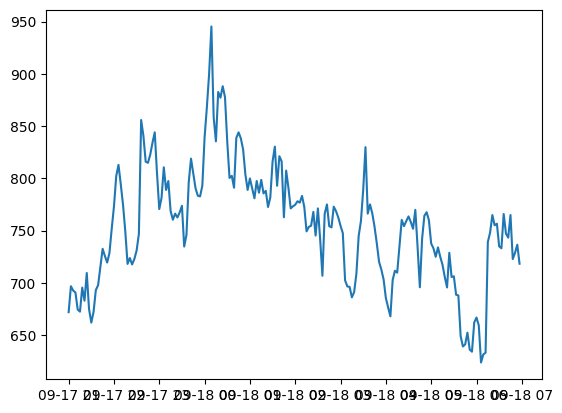

In [23]:
plt.plot(V)
V.loc[start].item(), V.max()

In [24]:
V_L1 = V.loc[start].item()
V_solar = 1215

V_avg = (V_L1 + V_solar) / 2

Delta_t = (1.5*10**8)/(V_avg*3600)
Delta_t


44.16570974295556